# Aim
The purpose of this notebook is to show how to use JIT to tune a resnet model.

In [ ]:
%%capture
%load_ext autoreload
%autoreload 2
%cd ../..
%pwd
%pip install timm>=1.0.14 transformers>=4.54,<5 matplotlib

In [2]:
from aitune.torch import patch_for_jit_tuning, PatchedModule
from aitune.torch import jit_config as config
import timm
import torch

from notebooks.jit.jit_commons import visualize_latency

/home/pbazan/sources/ai-tune/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/pbazan/sources/ai-tune/.venv/lib/python3.10/site-packages/modelopt/torch/utils/import_utils.py:32: UserWarning: Failed to import huggingface plugin due to: AttributeError("module 'transformers.modeling_utils' has no attribute 'Conv1D'"). You may ignore this warning if you do not need this plugin.
  warnings.warn(
[NeMo W 2026-01-27 15:58:06 nemo_logging:361] /home/pbazan/sources/ai-tune/.venv/lib/python3.10/site-packages/modelopt/torch/__init__.py:36: UserWarning: transformers version 4.57.1 is incompatible with nvidia-modelopt and may cause issues. Please install recommended version with `pip install nvidia-modelopt[hf]` if working with HF models.
      _warnings.warn(
    
TensorRT-LLM is not installed. Please ins

[01/27/2026-15:58:06] [TRT] [W] Functionality provided through tensorrt.plugin module is experimental.


# Resnet

In [3]:
@patch_for_jit_tuning
def create_resnet():
    return timm.create_model("resnet18", pretrained=False).to("cuda")


In [4]:
resnet = create_resnet()

In [5]:
config.min_samples = 4 # just to compare before and after tuning
config.dry_run = False
config.max_depth_level = 3
config.detect_graph_breaks = True

15:58:08.696 - WARNING - /home/pbazan/sources/ai-tune/.venv/lib/python3.10/site-packages/torch/_inductor/compile_fx.py:236: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(

15:58:11.492 - INFO - ------------------------------------------------------------
15:58:11.493 - INFO - 🚀 Tuning graph `0` for module `ResNet 📊11.7M`:
15:58:11.493 - INFO -   number of parameters: 11689512
15:58:11.494 - INFO -   number of layers: 10
15:58:11.494 - INFO -   precisions: torch.float32
15:58:11.494 - INFO -   graph_spec:
15:58:11.495 - INFO -     input_spec:
 Tensors:
╒═══════════╤════════╤═══════════════════════╤══════════════════╤═══════════════════╤═══════════════╕
│ Locator   │ Name   │ Shape                 │ Min Shape        │ Max Shape         │ Dtype         │
╞═══════════╪════════╪═══════════════════════╪══════════════════╪════════════════

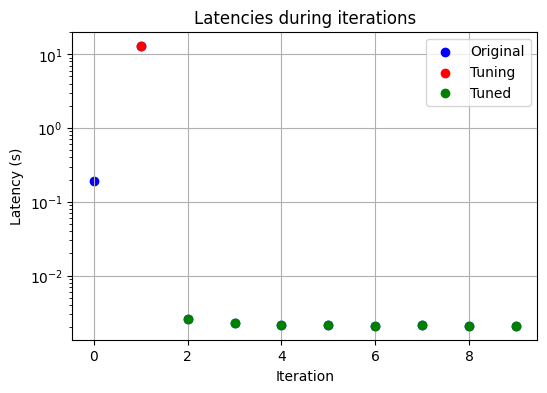

In [6]:
def batch():
    with torch.no_grad():
        # we are calling two times with different batch sizes to recognize dynamic axes
        resnet(torch.randn(2, 3, 224, 224, device="cuda"))
        resnet(torch.randn(16, 3, 224, 224, device="cuda"))

# this will measure latency during calling batch function
visualize_latency(lambda: batch(), iterations=10)


Let's the see history of what happend under the hood.

In [12]:
PatchedModule.history

['New top module: ResNet 📊11.7M level=0🪜 state=init⏳ call_count=1',
 'New child module: Conv2d 📊9.4K level=1🪜 state=init⏳ call_count=1',
 'New child module: BatchNorm2d 📊128 level=1🪜 state=init⏳ call_count=1',
 'New child module: BasicBlock 📊74.0K level=1🪜 state=init⏳ call_count=1',
 'New child module: Conv2d 📊36.9K level=2🪜 state=init⏳ call_count=1',
 'New child module: BatchNorm2d 📊128 level=2🪜 state=init⏳ call_count=1',
 'New child module: Conv2d 📊36.9K level=2🪜 state=init⏳ call_count=1',
 'New child module: BatchNorm2d 📊128 level=2🪜 state=init⏳ call_count=1',
 'New child module: BasicBlock 📊74.0K level=1🪜 state=init⏳ call_count=1',
 'New child module: Conv2d 📊36.9K level=2🪜 state=init⏳ call_count=1',
 'New child module: BatchNorm2d 📊128 level=2🪜 state=init⏳ call_count=1',
 'New child module: Conv2d 📊36.9K level=2🪜 state=init⏳ call_count=1',
 'New child module: BatchNorm2d 📊128 level=2🪜 state=init⏳ call_count=1',
 'New child module: BasicBlock 📊230.1K level=1🪜 state=init⏳ call_count

Let's see detected model architecture.

In [8]:
PatchedModule.print_hierarchy()

JIT Tuning Hierarchy:
├─ ResNet 📊11.7M level=0🪜 state=tuned🎯 (TensorRTBackend) call_count=4
  ├─ Conv2d 📊9.4K level=1🪜 state=detached☑️ call_count=4
  ├─ BatchNorm2d 📊128 level=1🪜 state=detached☑️ call_count=4
  ├─ BasicBlock 📊74.0K level=1🪜 state=detached☑️ call_count=4
    ├─ Conv2d 📊36.9K level=2🪜 state=detached☑️ call_count=4
    ├─ BatchNorm2d 📊128 level=2🪜 state=detached☑️ call_count=4
    ├─ Conv2d 📊36.9K level=2🪜 state=detached☑️ call_count=4
    ├─ BatchNorm2d 📊128 level=2🪜 state=detached☑️ call_count=4
  ├─ BasicBlock 📊74.0K level=1🪜 state=detached☑️ call_count=4
    ├─ Conv2d 📊36.9K level=2🪜 state=detached☑️ call_count=4
    ├─ BatchNorm2d 📊128 level=2🪜 state=detached☑️ call_count=4
    ├─ Conv2d 📊36.9K level=2🪜 state=detached☑️ call_count=4
    ├─ BatchNorm2d 📊128 level=2🪜 state=detached☑️ call_count=4
  ├─ BasicBlock 📊230.1K level=1🪜 state=detached☑️ call_count=4
    ├─ Conv2d 📊73.7K level=2🪜 state=detached☑️ call_count=4
    ├─ BatchNorm2d 📊256 level=2🪜 state=detached☑️ c

Let's call tuned module.

In [9]:
resnet(torch.randn(8, 3, 224, 224, device="cuda")).shape

torch.Size([8, 1000])

In [10]:
resnet(torch.randn(16, 3, 224, 224, device="cuda")).shape

torch.Size([16, 1000])

Currently the problem is when we provide too big batch size.

In [11]:
resnet(torch.randn(32, 3, 224, 224, device="cuda")).shape

15:58:20.672 - ERROR - [TRT] IExecutionContext::setInputShape: Error Code 3: API Usage Error (Parameter check failed, condition: satisfyProfile. Set dimension [32,3,224,224] for tensor args_0 does not satisfy any optimization profiles. Valid range for profile 0: [2,3,224,224]..[16,3,224,224].)


torch.Size([16, 1000])